-------------**STRATEJİLER: RSI**----------
RSI (Göreceli Güç Endeksi) stratejisini içeren ve görselleştirmesiyle birlikte çalışan tam bir Python kodu sunuyorum. Bu kod, bir fiyat dizisi üzerinden RSI hesaplar, alış/satış sinyallerini belirler ve bunu grafikte gösterir.


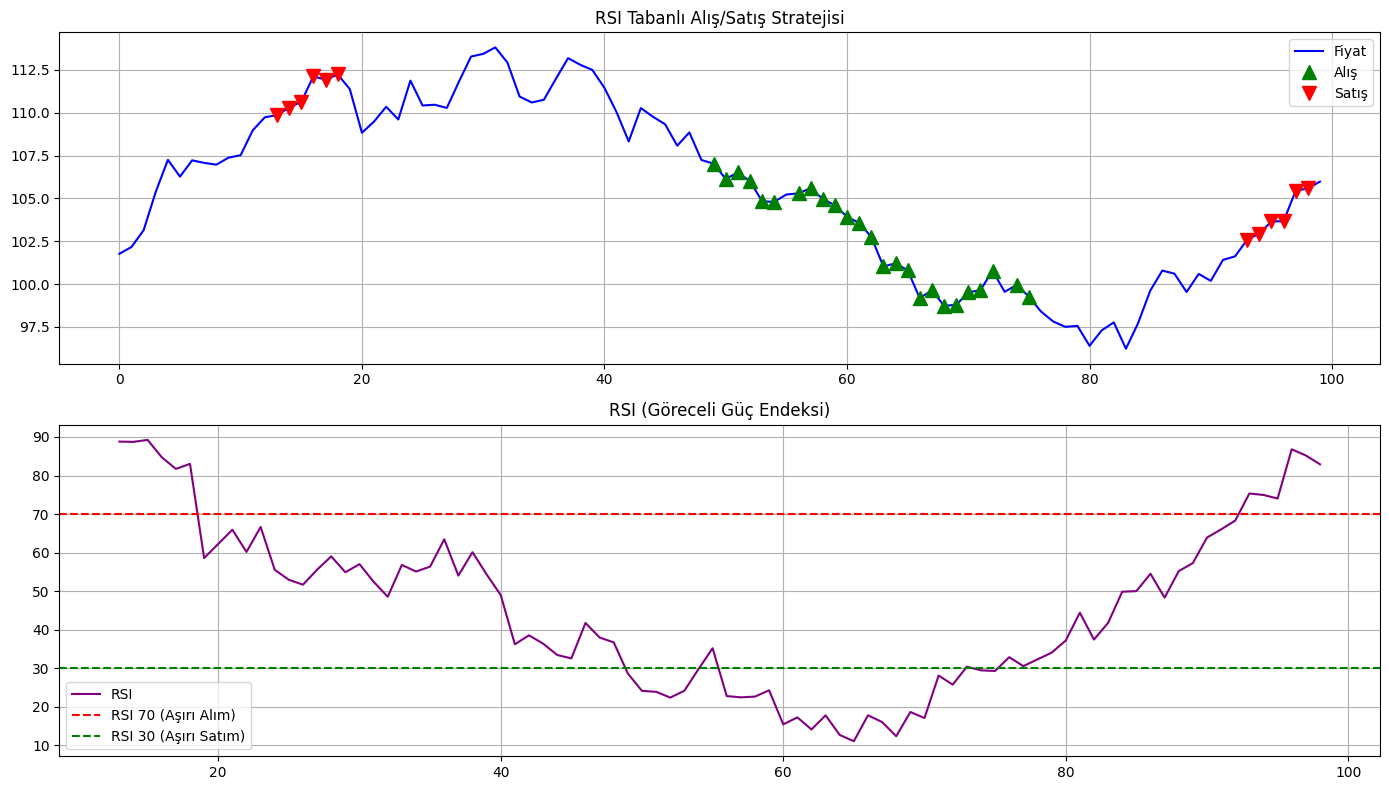

In [6]:
# RSI Tabanlı Yatırım Stratejisi ve Görselleştirme (Python + Matplotlib)
# Bu örnek RSI değerine göre alım-satım sinyalleri üretir ve bunları fiyat grafiği üzerinde işaretler.

import numpy as np
import matplotlib.pyplot as plt

def compute_rsi(prices, period=14):
    delta = np.diff(prices)
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)

    avg_gain = np.convolve(gain, np.ones(period)/period, mode='valid')
    avg_loss = np.convolve(loss, np.ones(period)/period, mode='valid')

    rs = avg_gain / (avg_loss + 1e-10)  # Avoid division by zero
    rsi = 100 - (100 / (1 + rs))

    return np.concatenate([np.full(period-1, np.nan), rsi])

def rsi_strategy(prices, rsi, lower=30, upper=70):
    signals = []
    for i in range(len(rsi)):
        if np.isnan(rsi[i]):
            signals.append(None)
        elif rsi[i] < lower:
            signals.append('buy')
        elif rsi[i] > upper:
            signals.append('sell')
        else:
            signals.append('hold')
    return signals

# Örnek fiyat verisi (istersen kendi verini koyabilirsin)
np.random.seed(0)
prices = np.cumsum(np.random.randn(100)) + 100

rsi = compute_rsi(prices)
signals = rsi_strategy(prices, rsi)

# Alış ve satış noktalarını belirleme
buy_signals = [prices[i] if s == 'buy' else np.nan for i, s in enumerate(signals)]
sell_signals = [prices[i] if s == 'sell' else np.nan for i, s in enumerate(signals)]

# Grafik
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(prices, label='Fiyat', color='blue')
plt.plot(buy_signals, 'g^', label='Alış', markersize=10)
plt.plot(sell_signals, 'rv', label='Satış', markersize=10)
plt.title('RSI Tabanlı Alış/Satış Stratejisi')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(rsi, label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='RSI 70 (Aşırı Alım)')
plt.axhline(30, color='green', linestyle='--', label='RSI 30 (Aşırı Satım)')
plt.title('RSI (Göreceli Güç Endeksi)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()
